In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset from the Excel file
df = pd.read_excel('TX_Power_Distances_Dataset.xlsx')

# Drop the specified columns
df.drop(columns=['Test', 'Throughput (KB/S)'], inplace=True)

# Clean up any extra unnamed columns if present (assuming first 5 relevant columns after drop)
# Columns should now be: Tx Power, Distance, Obstacles, RSSI, Throughput (Kbps), possibly extras
# Limit to relevant columns
df = df[['Tx Power', 'Distance', 'Obstacles', 'RSSI', 'Throughput (Kbps)']]

# Replace 'Non' and 'non' with NaN and convert to numeric where appropriate
df['RSSI'] = pd.to_numeric(df['RSSI'], errors='coerce')
df['Throughput (Kbps)'] = pd.to_numeric(df['Throughput (Kbps)'], errors='coerce')

# Drop rows with NaN values
df.dropna(inplace=True)

# Encode categorical 'Obstacles' column
df['Obstacles'] = df['Obstacles'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df.drop('Tx Power', axis=1)
y = df['Tx Power']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
predictions = clf.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Optional: Print confusion matrix or other metrics if needed
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

Accuracy: 0.43
              precision    recall  f1-score   support

          N0       1.00      0.67      0.80         3
         N12       0.00      0.00      0.00         1
          N6       0.00      0.00      0.00         1
          p9       0.25      0.50      0.33         2

    accuracy                           0.43         7
   macro avg       0.31      0.29      0.28         7
weighted avg       0.50      0.43      0.44         7



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Load the dataset from the Excel file
df = pd.read_excel('TX_Power_Distances_Dataset.xlsx')

# Drop the specified columns
df.drop(columns=['Test', 'Throughput (KB/S)'], inplace=True)

# Limit to relevant columns
df = df[['Tx Power', 'Distance', 'Obstacles', 'RSSI', 'Throughput (Kbps)']]

# Replace 'Non' and 'non' with NaN and convert to numeric where appropriate
df['RSSI'] = pd.to_numeric(df['RSSI'], errors='coerce')
df['Throughput (Kbps)'] = pd.to_numeric(df['Throughput (Kbps)'], errors='coerce')

# Drop rows with NaN values
df.dropna(inplace=True)

# Encode categorical 'Obstacles' column
df['Obstacles'] = df['Obstacles'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df.drop('Tx Power', axis=1)
y = df['Tx Power']

# Train the classifier on all data for better predictions (small dataset)
clf = RandomForestClassifier(random_state=42)
clf.fit(X, y)

# Example new values to predict on
# Format: [[Distance, Obstacles (1 for Yes, 0 for No), RSSI, Throughput (Kbps)]]
new_values = [
    [10, 1, -77, 71.6],  # Example 1
    [0, 0, -37, 105.47],  # Example 2
    [20, 0, -75, 76.1]    # Example 3
]

# Convert to DataFrame with same columns
new_df = pd.DataFrame(new_values, columns=X.columns)

# Make predictions
predictions = clf.predict(new_df)

# Print the predictions
for i, pred in enumerate(predictions):
    print(f"Prediction for example {i+1}: {pred}")

Dataset shape after cleaning: (142, 12)

TX Power levels in dataset: [-12, -9, -6, -3, 0, 3, 6, 9]

PART 1: THROUGHPUT PREDICTION MODEL
Throughput Model Performance:
  MSE: 188.22
  R²: 0.772
  MAE: 11.56 Kbps

PART 2: POWER CONSUMPTION PREDICTION MODEL
Power Model Performance:
  MSE: 0.000011
  R²: 0.991
  MAE: 0.001 W

PART 3: TX POWER OPTIMIZATION ALGORITHM

OPTIMIZATION EXAMPLES

Scenario 1:
  Conditions: RSSI=-70dBm, Distance=10m
  Environment: Lobby, Battery=80%
  Recommendation:
    TX Power: 6 dBm
    Predicted Throughput: 100.7 Kbps
    Predicted Power: 0.413 W
    Power Efficiency: 243.9 Kbps/W
    Meets Target: True

Scenario 2:
  Conditions: RSSI=-85dBm, Distance=20m
  Environment: Wall, Battery=30%
  Recommendation:
    TX Power: 9 dBm
    Predicted Throughput: 86.9 Kbps
    Predicted Power: 0.447 W
    Power Efficiency: 194.5 Kbps/W
    Meets Target: True

Scenario 3:
  Conditions: RSSI=-55dBm, Distance=5m
  Environment: Workshop, Battery=100%
  Recommendation:
    TX Pow

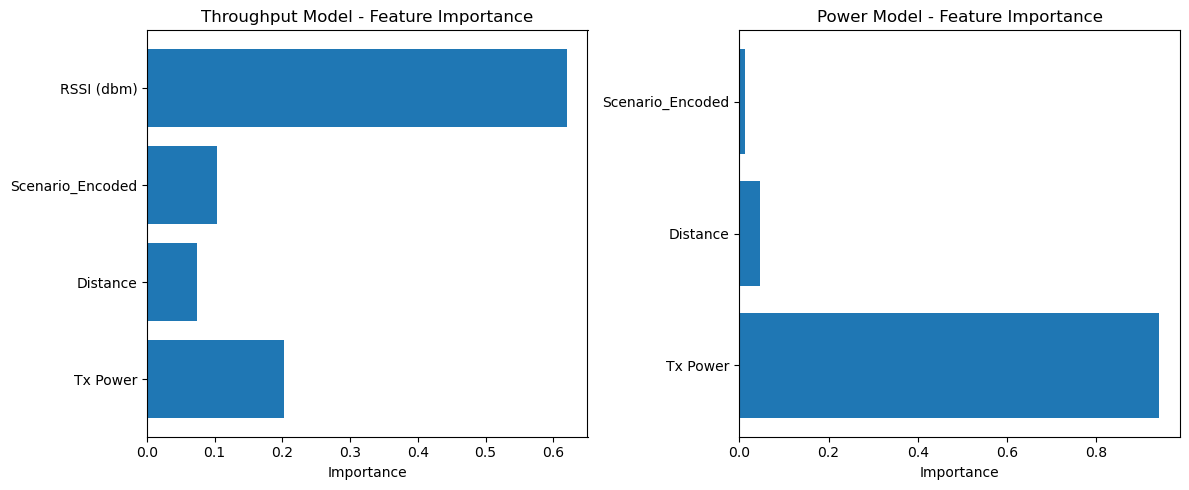

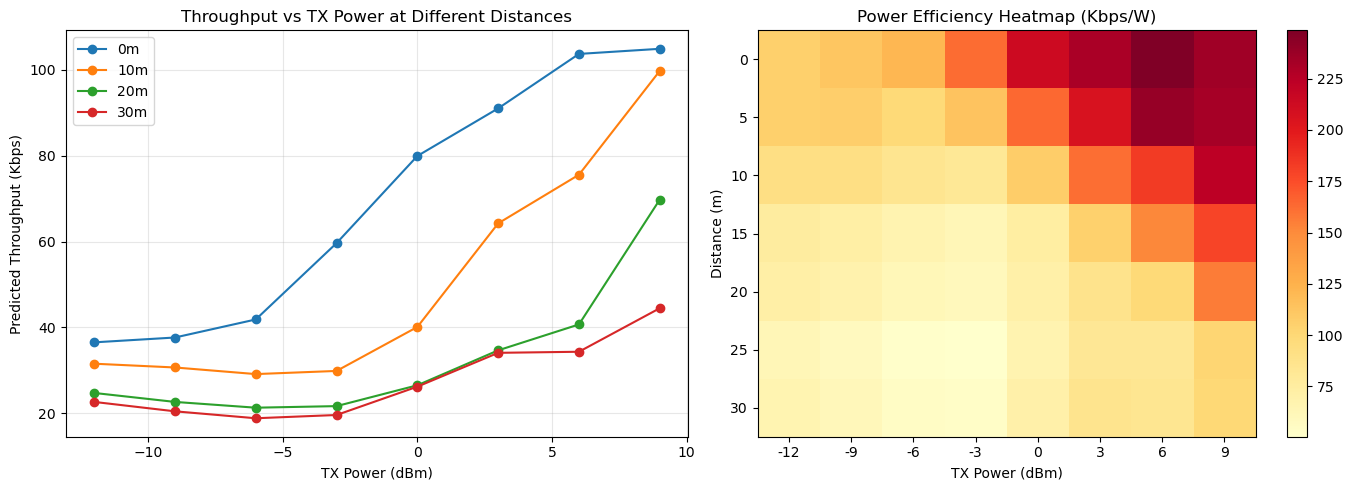

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('TX_Power_Distances_Dataset.csv')

# Clean column names
df.columns = df.columns.str.strip()

# Map TX power levels to numerical values (higher number = higher power)
tx_power_mapping = {
    'N12': -12,  # Lowest power
    'N9': -9,
    'N6': -6,
    'N3': -3,
    'N0': 0,
    'P3': 3,
    'P6': 6,
    'p9': 9,  # Highest power
    'P9': 9
}

# Apply mapping
df['Tx Power'] = df['Tx Power'].str.upper().map(lambda x: tx_power_mapping.get(x, x))
df['Tx Power'] = df['Tx Power'].replace({'P9': 9})

# Clean and prepare data
df['RSSI (dbm)'] = pd.to_numeric(df['RSSI (dbm)'], errors='coerce')
df['Throughput (Kbps)'] = pd.to_numeric(df['Throughput (Kbps)'], errors='coerce')
df['Current (A)'] = pd.to_numeric(df['Current (A)'], errors='coerce')
df['Power (W)'] = pd.to_numeric(df['Power (W)'], errors='coerce')
df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

# Create power efficiency metric (Kbps per Watt)
df['Power_Efficiency'] = df['Throughput (Kbps)'] / df['Power (W)']

# Encode scenarios
le_scenario = LabelEncoder()
df['Scenario_Encoded'] = le_scenario.fit_transform(df['Senarios'])

# Drop rows with NaN values
df_clean = df.dropna(subset=['Tx Power', 'RSSI (dbm)', 'Throughput (Kbps)', 'Power (W)'])

print("Dataset shape after cleaning:", df_clean.shape)
print("\nTX Power levels in dataset:", sorted(df_clean['Tx Power'].unique()))

# ==================== PART 1: THROUGHPUT PREDICTION MODEL ====================
print("\n" + "="*60)
print("PART 1: THROUGHPUT PREDICTION MODEL")
print("="*60)

# Features for throughput prediction
throughput_features = ['Tx Power', 'Distance', 'Scenario_Encoded', 'RSSI (dbm)']
X_throughput = df_clean[throughput_features]
y_throughput = df_clean['Throughput (Kbps)']

# Split data
X_tp_train, X_tp_test, y_tp_train, y_tp_test = train_test_split(
    X_throughput, y_throughput, test_size=0.2, random_state=42
)

# Scale features
scaler_throughput = StandardScaler()
X_tp_train_scaled = scaler_throughput.fit_transform(X_tp_train)
X_tp_test_scaled = scaler_throughput.transform(X_tp_test)

# Train Random Forest for throughput prediction
rf_throughput = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_throughput.fit(X_tp_train_scaled, y_tp_train)

# Evaluate throughput model
y_tp_pred = rf_throughput.predict(X_tp_test_scaled)
tp_mse = mean_squared_error(y_tp_test, y_tp_pred)
tp_r2 = r2_score(y_tp_test, y_tp_pred)
tp_mae = mean_absolute_error(y_tp_test, y_tp_pred)

print(f"Throughput Model Performance:")
print(f"  MSE: {tp_mse:.2f}")
print(f"  R²: {tp_r2:.3f}")
print(f"  MAE: {tp_mae:.2f} Kbps")

# ==================== PART 2: POWER CONSUMPTION PREDICTION MODEL ====================
print("\n" + "="*60)
print("PART 2: POWER CONSUMPTION PREDICTION MODEL")
print("="*60)

# Features for power prediction
power_features = ['Tx Power', 'Distance', 'Scenario_Encoded']
X_power = df_clean[power_features]
y_power = df_clean['Power (W)']

# Split data
X_pw_train, X_pw_test, y_pw_train, y_pw_test = train_test_split(
    X_power, y_power, test_size=0.2, random_state=42
)

# Scale features
scaler_power = StandardScaler()
X_pw_train_scaled = scaler_power.fit_transform(X_pw_train)
X_pw_test_scaled = scaler_power.transform(X_pw_test)

# Train Gradient Boosting for power prediction
gb_power = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_power.fit(X_pw_train_scaled, y_pw_train)

# Evaluate power model
y_pw_pred = gb_power.predict(X_pw_test_scaled)
pw_mse = mean_squared_error(y_pw_test, y_pw_pred)
pw_r2 = r2_score(y_pw_test, y_pw_pred)
pw_mae = mean_absolute_error(y_pw_test, y_pw_pred)

print(f"Power Model Performance:")
print(f"  MSE: {pw_mse:.6f}")
print(f"  R²: {pw_r2:.3f}")
print(f"  MAE: {pw_mae:.3f} W")

# ==================== PART 3: TX POWER OPTIMIZER ====================
print("\n" + "="*60)
print("PART 3: TX POWER OPTIMIZATION ALGORITHM")
print("="*60)

class TxPowerOptimizer:
    """
    ML-based TX Power Optimizer that balances throughput maximization 
    with power consumption minimization
    """
    
    def __init__(self, throughput_model, power_model, 
                 throughput_scaler, power_scaler, 
                 scenario_encoder):
        self.throughput_model = throughput_model
        self.power_model = power_model
        self.throughput_scaler = throughput_scaler
        self.power_scaler = power_scaler
        self.scenario_encoder = scenario_encoder
        
        # TX power levels available
        self.tx_power_levels = [-12, -9, -6, -3, 0, 3, 6, 9]
        
        # Optimization parameters
        self.throughput_target = 50  # Minimum acceptable throughput (Kbps)
        self.throughput_weight = 0.6  # Weight for throughput vs power
        self.power_weight = 0.4       # Weight for power efficiency
        
    def predict_throughput(self, tx_power, distance, scenario, rssi):
        """Predict throughput for given conditions"""
        try:
            scenario_encoded = self.scenario_encoder.transform([scenario])[0]
        except:
            scenario_encoded = 0  # Default to first scenario if unknown
            
        features = np.array([[tx_power, distance, scenario_encoded, rssi]])
        features_scaled = self.throughput_scaler.transform(features)
        return self.throughput_model.predict(features_scaled)[0]
    
    def predict_power(self, tx_power, distance, scenario):
        """Predict power consumption for given conditions"""
        try:
            scenario_encoded = self.scenario_encoder.transform([scenario])[0]
        except:
            scenario_encoded = 0
            
        features = np.array([[tx_power, distance, scenario_encoded]])
        features_scaled = self.power_scaler.transform(features)
        return self.power_model.predict(features_scaled)[0]
    
    def calculate_efficiency_score(self, throughput, power):
        """Calculate efficiency score combining throughput and power"""
        if power == 0:
            return 0
        
        # Normalize throughput (0-100 scale)
        throughput_norm = min(throughput / 100, 1.0)
        
        # Normalize power (inverse, lower is better)
        power_norm = 1 - min(power / 0.5, 1.0)  # 0.5W as max expected
        
        # Weighted combination
        score = (self.throughput_weight * throughput_norm + 
                self.power_weight * power_norm)
        
        # Penalty if below minimum throughput
        if throughput < self.throughput_target:
            score *= (throughput / self.throughput_target) ** 2
            
        return score
    
    def optimize_tx_power(self, current_rssi, distance, scenario, 
                         current_throughput=None, battery_level=100):
        """
        Find optimal TX power setting for current conditions
        
        Args:
            current_rssi: Current RSSI measurement (dBm)
            distance: Distance from access point (meters)
            scenario: Environment type ('Wall', 'Lobby', 'Crowded', 'Workshop')
            current_throughput: Current measured throughput if available
            battery_level: Battery percentage (affects optimization strategy)
        
        Returns:
            dict: Optimization results with recommended TX power and predictions
        """
        
        # Adjust weights based on battery level
        if battery_level < 20:
            self.throughput_weight = 0.3
            self.power_weight = 0.7
        elif battery_level < 50:
            self.throughput_weight = 0.5
            self.power_weight = 0.5
        else:
            self.throughput_weight = 0.6
            self.power_weight = 0.4
        
        results = []
        
        # Evaluate each TX power level
        for tx_power in self.tx_power_levels:
            # Estimate RSSI for this TX power (simplified model)
            # In reality, you'd need a more sophisticated RSSI prediction
            estimated_rssi = current_rssi + (tx_power - self.tx_power_levels[3]) * 2
            estimated_rssi = max(-100, min(-30, estimated_rssi))  # Clamp values
            
            # Predict throughput and power
            pred_throughput = self.predict_throughput(
                tx_power, distance, scenario, estimated_rssi
            )
            pred_power = self.predict_power(tx_power, distance, scenario)
            
            # Calculate efficiency score
            efficiency = self.calculate_efficiency_score(pred_throughput, pred_power)
            
            results.append({
                'tx_power': tx_power,
                'predicted_throughput': pred_throughput,
                'predicted_power': pred_power,
                'efficiency_score': efficiency,
                'power_efficiency': pred_throughput / pred_power if pred_power > 0 else 0
            })
        
        # Sort by efficiency score
        results.sort(key=lambda x: x['efficiency_score'], reverse=True)
        
        # Select best option that meets minimum throughput
        best_option = results[0]
        for option in results:
            if option['predicted_throughput'] >= self.throughput_target:
                best_option = option
                break
        
        # Prepare recommendation
        recommendation = {
            'recommended_tx_power': best_option['tx_power'],
            'predicted_throughput': best_option['predicted_throughput'],
            'predicted_power': best_option['predicted_power'],
            'efficiency_score': best_option['efficiency_score'],
            'power_efficiency_kbps_per_watt': best_option['power_efficiency'],
            'meets_throughput_target': best_option['predicted_throughput'] >= self.throughput_target,
            'all_options': results[:3]  # Top 3 options
        }
        
        return recommendation
    
    def adaptive_control(self, measurements_history):
        """
        Adaptive control based on historical measurements
        
        Args:
            measurements_history: List of dicts with recent measurements
                Each dict should have: rssi, throughput, power, tx_power, distance, scenario
        
        Returns:
            dict: Adaptive control recommendation
        """
        if not measurements_history:
            return None
        
        recent = measurements_history[-1]
        
        # Check if we're meeting targets
        current_throughput = recent.get('throughput', 0)
        current_power = recent.get('power', 0.5)
        
        # Get optimization recommendation
        recommendation = self.optimize_tx_power(
            recent['rssi'], 
            recent['distance'],
            recent['scenario'],
            current_throughput
        )
        
        # Add adaptive adjustments
        if len(measurements_history) >= 3:
            # Check trend
            throughput_trend = np.mean([m['throughput'] for m in measurements_history[-3:]]) 
            
            if throughput_trend < self.throughput_target * 0.8:
                # Throughput critically low, be more aggressive
                recommendation['adjustment'] = 'INCREASE_AGGRESSIVE'
            elif current_throughput > self.throughput_target * 1.5:
                # We have headroom, can reduce power
                recommendation['adjustment'] = 'DECREASE_GRADUAL'
            else:
                recommendation['adjustment'] = 'MAINTAIN'
        
        return recommendation

# Initialize optimizer
optimizer = TxPowerOptimizer(
    rf_throughput, gb_power, 
    scaler_throughput, scaler_power,
    le_scenario
)

# ==================== DEMONSTRATION ====================
print("\n" + "="*60)
print("OPTIMIZATION EXAMPLES")
print("="*60)

# Test scenarios
test_scenarios = [
    {"rssi": -70, "distance": 10, "scenario": "Lobby", "battery": 80},
    {"rssi": -85, "distance": 20, "scenario": "Wall", "battery": 30},
    {"rssi": -55, "distance": 5, "scenario": "Workshop", "battery": 100},
]

for i, test in enumerate(test_scenarios, 1):
    print(f"\nScenario {i}:")
    print(f"  Conditions: RSSI={test['rssi']}dBm, Distance={test['distance']}m")
    print(f"  Environment: {test['scenario']}, Battery={test['battery']}%")
    
    result = optimizer.optimize_tx_power(
        test['rssi'], test['distance'], 
        test['scenario'], battery_level=test['battery']
    )
    
    print(f"  Recommendation:")
    print(f"    TX Power: {result['recommended_tx_power']} dBm")
    print(f"    Predicted Throughput: {result['predicted_throughput']:.1f} Kbps")
    print(f"    Predicted Power: {result['predicted_power']:.3f} W")
    print(f"    Power Efficiency: {result['power_efficiency_kbps_per_watt']:.1f} Kbps/W")
    print(f"    Meets Target: {result['meets_throughput_target']}")

# ==================== VISUALIZATION ====================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# Feature importance plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Throughput model feature importance
importance_tp = rf_throughput.feature_importances_
features_tp = throughput_features
axes[0].barh(features_tp, importance_tp)
axes[0].set_xlabel('Importance')
axes[0].set_title('Throughput Model - Feature Importance')

# Power model feature importance
importance_pw = gb_power.feature_importances_
features_pw = power_features
axes[1].barh(features_pw, importance_pw)
axes[1].set_xlabel('Importance')
axes[1].set_title('Power Model - Feature Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# Optimization surface plot
fig = plt.figure(figsize=(14, 5))

# Plot 1: Throughput vs TX Power for different distances
ax1 = fig.add_subplot(121)
for distance in [0, 10, 20, 30]:
    throughputs = []
    tx_powers = optimizer.tx_power_levels
    
    for tx_power in tx_powers:
        rssi_est = -40 - distance * 2 - (9 - tx_power) * 3
        tp = optimizer.predict_throughput(tx_power, distance, "Lobby", rssi_est)
        throughputs.append(tp)
    
    ax1.plot(tx_powers, throughputs, marker='o', label=f'{distance}m')

ax1.set_xlabel('TX Power (dBm)')
ax1.set_ylabel('Predicted Throughput (Kbps)')
ax1.set_title('Throughput vs TX Power at Different Distances')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Power Efficiency Heatmap
ax2 = fig.add_subplot(122)
distances = range(0, 35, 5)
tx_powers = optimizer.tx_power_levels

efficiency_matrix = []
for distance in distances:
    row = []
    for tx_power in tx_powers:
        rssi_est = -40 - distance * 2 - (9 - tx_power) * 3
        tp = optimizer.predict_throughput(tx_power, distance, "Lobby", rssi_est)
        pw = optimizer.predict_power(tx_power, distance, "Lobby")
        efficiency = tp / pw if pw > 0 else 0
        row.append(efficiency)
    efficiency_matrix.append(row)

im = ax2.imshow(efficiency_matrix, aspect='auto', cmap='YlOrRd')
ax2.set_xticks(range(len(tx_powers)))
ax2.set_xticklabels(tx_powers)
ax2.set_yticks(range(len(list(distances))))
ax2.set_yticklabels(list(distances))
ax2.set_xlabel('TX Power (dBm)')
ax2.set_ylabel('Distance (m)')
ax2.set_title('Power Efficiency Heatmap (Kbps/W)')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.savefig('optimization_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')

def visualize_classifier_results(classifier, df, X, y):
    """
    Create comprehensive visualization of classifier results
    
    Parameters:
    - classifier: Trained AdaptiveTXPowerClassifier object
    - df: Original dataframe with all data
    - X: Feature matrix used for training
    - y: Target labels
    """
    
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))
    
    # ============= 1. Enhanced Confusion Matrix =============
    ax1 = plt.subplot(3, 4, 1)
    
    # Get predictions for the full dataset
    X_scaled = classifier.scaler.transform(X)
    y_pred = classifier.model.predict(X_scaled)
    y_true = classifier.label_encoder.transform(y)
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot confusion matrix with percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classifier.label_encoder.classes_,
                yticklabels=classifier.label_encoder.classes_,
                cbar_kws={'label': 'Count'})
    ax1.set_xlabel('Predicted TX Power', fontsize=10, fontweight='bold')
    ax1.set_ylabel('True TX Power', fontsize=10, fontweight='bold')
    ax1.set_title('Confusion Matrix - Absolute Values', fontsize=12, fontweight='bold')
    
    # ============= 2. Normalized Confusion Matrix =============
    ax2 = plt.subplot(3, 4, 2)
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=classifier.label_encoder.classes_,
                yticklabels=classifier.label_encoder.classes_,
                cbar_kws={'label': 'Accuracy'})
    ax2.set_xlabel('Predicted TX Power', fontsize=10, fontweight='bold')
    ax2.set_ylabel('True TX Power', fontsize=10, fontweight='bold')
    ax2.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
    
    # ============= 3. Prediction Distribution =============
    ax3 = plt.subplot(3, 4, 3)
    
    tx_powers = classifier.label_encoder.classes_
    pred_counts = pd.Series(classifier.label_encoder.inverse_transform(y_pred)).value_counts()
    true_counts = pd.Series(y).value_counts()
    
    x_pos = np.arange(len(tx_powers))
    width = 0.35
    
    pred_values = [pred_counts.get(tx, 0) for tx in tx_powers]
    true_values = [true_counts.get(tx, 0) for tx in tx_powers]
    
    bars1 = ax3.bar(x_pos - width/2, true_values, width, label='True', alpha=0.8, color='skyblue')
    bars2 = ax3.bar(x_pos + width/2, pred_values, width, label='Predicted', alpha=0.8, color='lightcoral')
    
    ax3.set_xlabel('TX Power Level', fontsize=10, fontweight='bold')
    ax3.set_ylabel('Count', fontsize=10, fontweight='bold')
    ax3.set_title('Distribution: True vs Predicted', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(tx_powers, rotation=45)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    # ============= 4. Per-Class Accuracy =============
    ax4 = plt.subplot(3, 4, 4)
    
    class_accuracy = []
    for i, tx_power in enumerate(tx_powers):
        if cm[i].sum() > 0:
            accuracy = cm[i, i] / cm[i].sum()
        else:
            accuracy = 0
        class_accuracy.append(accuracy)
    
    colors = ['green' if acc >= 0.8 else 'orange' if acc >= 0.6 else 'red' for acc in class_accuracy]
    bars = ax4.bar(range(len(tx_powers)), class_accuracy, color=colors, alpha=0.7)
    
    ax4.set_xlabel('TX Power Level', fontsize=10, fontweight='bold')
    ax4.set_ylabel('Accuracy', fontsize=10, fontweight='bold')
    ax4.set_title('Per-Class Accuracy', fontsize=12, fontweight='bold')
    ax4.set_xticks(range(len(tx_powers)))
    ax4.set_xticklabels(tx_powers, rotation=45)
    ax4.set_ylim([0, 1.1])
    ax4.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good (80%)')
    ax4.axhline(y=0.6, color='orange', linestyle='--', alpha=0.5, label='Fair (60%)')
    ax4.legend(loc='lower right')
    ax4.grid(True, alpha=0.3)
    
    # Add percentage labels
    for bar, acc in zip(bars, class_accuracy):
        ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{acc:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # ============= 5. RSSI vs Predicted TX Power =============
    ax5 = plt.subplot(3, 4, 5)
    
    df['Predicted_TX_Power'] = classifier.label_encoder.inverse_transform(y_pred)
    
    for tx_power in tx_powers:
        mask = df['Predicted_TX_Power'] == tx_power
        if mask.sum() > 0:
            ax5.scatter(df.loc[mask, 'RSSI (dbm)'], 
                       df.loc[mask, 'Throughput (Kbps)'],
                       label=tx_power, alpha=0.6, s=30)
    
    ax5.set_xlabel('RSSI (dBm)', fontsize=10, fontweight='bold')
    ax5.set_ylabel('Throughput (Kbps)', fontsize=10, fontweight='bold')
    ax5.set_title('RSSI vs Throughput by Predicted TX Power', fontsize=12, fontweight='bold')
    ax5.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax5.grid(True, alpha=0.3)
    ax5.axhline(y=classifier.throughput_target, color='red', linestyle='--', 
               alpha=0.5, label=f'Target: {classifier.throughput_target}')
    
    # ============= 6. Power Efficiency Analysis =============
    ax6 = plt.subplot(3, 4, 6)
    
    df['Efficiency_Score'] = df.apply(
        lambda x: classifier.calculate_efficiency_score(x['Throughput (Kbps)'], x['Power (W)']), 
        axis=1
    )
    
    efficiency_by_pred = df.groupby('Predicted_TX_Power')['Efficiency_Score'].agg(['mean', 'std'])
    efficiency_by_pred = efficiency_by_pred.reindex(tx_powers, fill_value=0)
    
    x_pos = np.arange(len(tx_powers))
    bars = ax6.bar(x_pos, efficiency_by_pred['mean'], 
                   yerr=efficiency_by_pred['std'], 
                   capsize=5, alpha=0.7,
                   color=['green' if i < 5 else 'orange' for i in range(len(tx_powers))])
    
    ax6.set_xlabel('Predicted TX Power', fontsize=10, fontweight='bold')
    ax6.set_ylabel('Efficiency Score', fontsize=10, fontweight='bold')
    ax6.set_title('Average Efficiency by Predicted TX Power', fontsize=12, fontweight='bold')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(tx_powers, rotation=45)
    ax6.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, mean_val in zip(bars, efficiency_by_pred['mean']):
        if mean_val > 0:
            ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{mean_val:.2f}', ha='center', va='bottom', fontsize=8)
    
    # ============= 7. Misclassification Analysis =============
    ax7 = plt.subplot(3, 4, 7)
    
    # Find misclassified samples
    misclassified_mask = y_true != y_pred
    misclassified_df = df[misclassified_mask].copy()
    
    if len(misclassified_df) > 0:
        scatter = ax7.scatter(misclassified_df['RSSI (dbm)'], 
                            misclassified_df['Power (W)'],
                            c=misclassified_df['Throughput (Kbps)'],
                            cmap='coolwarm', s=50, alpha=0.7)
        plt.colorbar(scatter, ax=ax7, label='Throughput (Kbps)')
        ax7.set_xlabel('RSSI (dBm)', fontsize=10, fontweight='bold')
        ax7.set_ylabel('Power (W)', fontsize=10, fontweight='bold')
        ax7.set_title(f'Misclassified Samples (n={len(misclassified_df)})', 
                     fontsize=12, fontweight='bold')
    else:
        ax7.text(0.5, 0.5, 'No misclassified samples!', 
                ha='center', va='center', transform=ax7.transAxes,
                fontsize=14, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    
    # ============= 8. Feature Importance (if available) =============
    ax8 = plt.subplot(3, 4, 8)
    
    if classifier.feature_importance is not None:
        top_features = classifier.feature_importance.head(10)
        
        # Identify primary features
        primary_features = ['RSSI', 'Throughput', 'Power']
        colors = ['red' if any(pf in feat for pf in primary_features) else 'blue' 
                 for feat in top_features['feature']]
        
        bars = ax8.barh(range(len(top_features)), top_features['importance'], color=colors, alpha=0.7)
        ax8.set_yticks(range(len(top_features)))
        ax8.set_yticklabels(top_features['feature'], fontsize=9)
        ax8.set_xlabel('Importance', fontsize=10, fontweight='bold')
        ax8.set_title('Top 10 Feature Importance', fontsize=12, fontweight='bold')
        ax8.grid(True, alpha=0.3)
        
        # Add value labels
        for bar, val in zip(bars, top_features['importance']):
            ax8.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', ha='left', va='center', fontsize=8)
    else:
        ax8.text(0.5, 0.5, 'Feature importance not available', 
                ha='center', va='center', transform=ax8.transAxes)
    
    # ============= 9. Prediction Confidence Distribution =============
    ax9 = plt.subplot(3, 4, 9)
    
    # Get prediction probabilities
    y_proba = classifier.model.predict_proba(X_scaled)
    max_proba = np.max(y_proba, axis=1)
    
    ax9.hist(max_proba, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax9.axvline(x=0.5, color='red', linestyle='--', label='50% threshold')
    ax9.axvline(x=0.8, color='green', linestyle='--', label='80% confidence')
    ax9.set_xlabel('Prediction Confidence', fontsize=10, fontweight='bold')
    ax9.set_ylabel('Frequency', fontsize=10, fontweight='bold')
    ax9.set_title('Distribution of Prediction Confidence', fontsize=12, fontweight='bold')
    ax9.legend()
    ax9.grid(True, alpha=0.3)
    
    # Add statistics
    ax9.text(0.02, 0.95, f'Mean: {max_proba.mean():.3f}\nStd: {max_proba.std():.3f}',
            transform=ax9.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # ============= 10. Error by RSSI Range =============
    ax10 = plt.subplot(3, 4, 10)
    
    rssi_bins = [-100, -90, -80, -70, -60, -50, -40]
    rssi_labels = ['<-90', '-90 to -80', '-80 to -70', '-70 to -60', '-60 to -50', '>-50']
    df['RSSI_Range'] = pd.cut(df['RSSI (dbm)'], bins=rssi_bins, labels=rssi_labels)
    
    error_by_rssi = []
    counts_by_rssi = []
    for rssi_range in rssi_labels:
        mask = df['RSSI_Range'] == rssi_range
        if mask.sum() > 0:
            range_true = y_true[mask]
            range_pred = y_pred[mask]
            error_rate = (range_true != range_pred).mean()
            error_by_rssi.append(error_rate)
            counts_by_rssi.append(mask.sum())
        else:
            error_by_rssi.append(0)
            counts_by_rssi.append(0)
    
    x_pos = np.arange(len(rssi_labels))
    bars = ax10.bar(x_pos, error_by_rssi, alpha=0.7, color='coral')
    
    ax10.set_xlabel('RSSI Range (dBm)', fontsize=10, fontweight='bold')
    ax10.set_ylabel('Error Rate', fontsize=10, fontweight='bold')
    ax10.set_title('Classification Error by RSSI Range', fontsize=12, fontweight='bold')
    ax10.set_xticks(x_pos)
    ax10.set_xticklabels(rssi_labels, rotation=45, ha='right')
    ax10.set_ylim([0, max(error_by_rssi) * 1.2 if max(error_by_rssi) > 0 else 1])
    ax10.grid(True, alpha=0.3)
    
    # Add sample count and error rate labels
    for bar, error, count in zip(bars, error_by_rssi, counts_by_rssi):
        if count > 0:
            ax10.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{error:.1%}\n(n={count})', ha='center', va='bottom', fontsize=8)
    
    # ============= 11. 3D Scatter: Correct vs Incorrect =============
    ax11 = fig.add_subplot(3, 4, 11, projection='3d')
    
    correct_mask = y_true == y_pred
    
    # Plot correct predictions
    ax11.scatter(df.loc[correct_mask, 'RSSI (dbm)'], 
                df.loc[correct_mask, 'Throughput (Kbps)'],
                df.loc[correct_mask, 'Power (W)'],
                c='green', alpha=0.5, s=20, label='Correct')
    
    # Plot incorrect predictions
    ax11.scatter(df.loc[~correct_mask, 'RSSI (dbm)'], 
                df.loc[~correct_mask, 'Throughput (Kbps)'],
                df.loc[~correct_mask, 'Power (W)'],
                c='red', alpha=0.8, s=40, label='Incorrect', marker='^')
    
    ax11.set_xlabel('RSSI (dBm)', fontsize=9)
    ax11.set_ylabel('Throughput (Kbps)', fontsize=9)
    ax11.set_zlabel('Power (W)', fontsize=9)
    ax11.set_title('3D View: Correct vs Incorrect Predictions', fontsize=11, fontweight='bold')
    ax11.legend()
    
    # ============= 12. Performance Metrics Summary =============
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')
    
    # Calculate metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Create summary text
    summary_text = f"""
    PERFORMANCE METRICS SUMMARY
    {'='*40}
    
    Overall Accuracy: {accuracy:.3f}
    
    Macro-Averaged Metrics:
    • Precision: {precision_macro:.3f}
    • Recall: {recall_macro:.3f}
    • F1-Score: {f1_macro:.3f}
    
    Weighted-Averaged Metrics:
    • Precision: {precision_weighted:.3f}
    • Recall: {recall_weighted:.3f}
    • F1-Score: {f1_weighted:.3f}
    
    Model Information:
    • Type: {type(classifier.model).__name__}
    • Features: {X.shape[1]}
    • Samples: {len(df)}
    • Classes: {len(tx_powers)}
    
    Configuration:
    • Target Throughput: {classifier.throughput_target} Kbps
    • Efficiency Weight: {classifier.efficiency_weight:.1%}
    """
    
    ax12.text(0.1, 0.9, summary_text, transform=ax12.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # Overall title
    fig.suptitle('Adaptive TX Power Classifier - Comprehensive Performance Analysis', 
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()
    
    return fig

def plot_learning_curves(classifier, X, y):
    """
    Plot learning curves to analyze model training behavior
    """
    from sklearn.model_selection import learning_curve
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Encode labels
    y_encoded = classifier.label_encoder.transform(y)
    
    # Calculate learning curves
    train_sizes, train_scores, val_scores = learning_curve(
        classifier.model, 
        classifier.scaler.transform(X), 
        y_encoded,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    
    # Plot learning curves
    ax1 = axes[0]
    ax1.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='blue',
            label='Training accuracy', linewidth=2, markersize=8)
    ax1.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color='red',
            label='Validation accuracy', linewidth=2, markersize=8)
    
    # Add confidence intervals
    ax1.fill_between(train_sizes, 
                    np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                    np.mean(train_scores, axis=1) + np.std(train_scores, axis=1),
                    alpha=0.2, color='blue')
    ax1.fill_between(train_sizes,
                    np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                    np.mean(val_scores, axis=1) + np.std(val_scores, axis=1),
                    alpha=0.2, color='red')
    
    ax1.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Learning Curves', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0.5, 1.05])
    
    # Plot validation curve for different training sizes
    ax2 = axes[1]
    
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    
    # Calculate the gap
    gap = train_mean - val_mean
    
    ax2.plot(train_sizes, gap, 'o-', color='purple', linewidth=2, markersize=8)
    ax2.fill_between(train_sizes, 0, gap, alpha=0.3, color='purple')
    
    ax2.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Training-Validation Gap', fontsize=12, fontweight='bold')
    ax2.set_title('Generalization Gap Analysis', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='5% gap threshold')
    ax2.legend()
    
    plt.suptitle('Model Learning Behavior Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

# Example usage:
# Assuming you have already trained your classifier and have the necessary data
# visualize_classifier_results(classifier, df, X, y)
# plot_learning_curves(classifier, X, y)

# Adaptive Algorithm Using Original Dataset

ADAPTIVE TX POWER CLASSIFIER - 3 INPUT MODEL
Inputs: RSSI (dBm), Throughput (Kbps), Power (W)

Loading and preparing data...
Loaded 142 samples

Determining optimal TX powers based on efficiency...

Optimal TX Power Distribution:
Optimal_TX_Power
N0     31
N12    17
N3      8
N6     20
N9     12
P3     16
P6     13
p9     25
Name: count, dtype: int64

Creating features from 3 inputs...
Feature set size: (142, 15)
Features created: ['RSSI', 'Throughput', 'Power', 'Throughput_per_Watt', 'RSSI_Category', 'Throughput_Achievement', 'Power_Efficiency', 'Signal_Strength_Score', 'Efficiency_Score', 'RSSI_squared', 'Throughput_squared', 'Power_squared', 'RSSI_x_Throughput', 'RSSI_x_Power', 'Throughput_x_Power']

TRAINING ML MODEL
Training models with 3-input feature set (RSSI, Throughput, Power)...
------------------------------------------------------------
RandomForest         CV Score: 0.877 (+/- 0.062)
GradientBoosting     CV Score: 0.876 (+/- 0.101)
NeuralNetwork        CV Score: 0.752 (+/

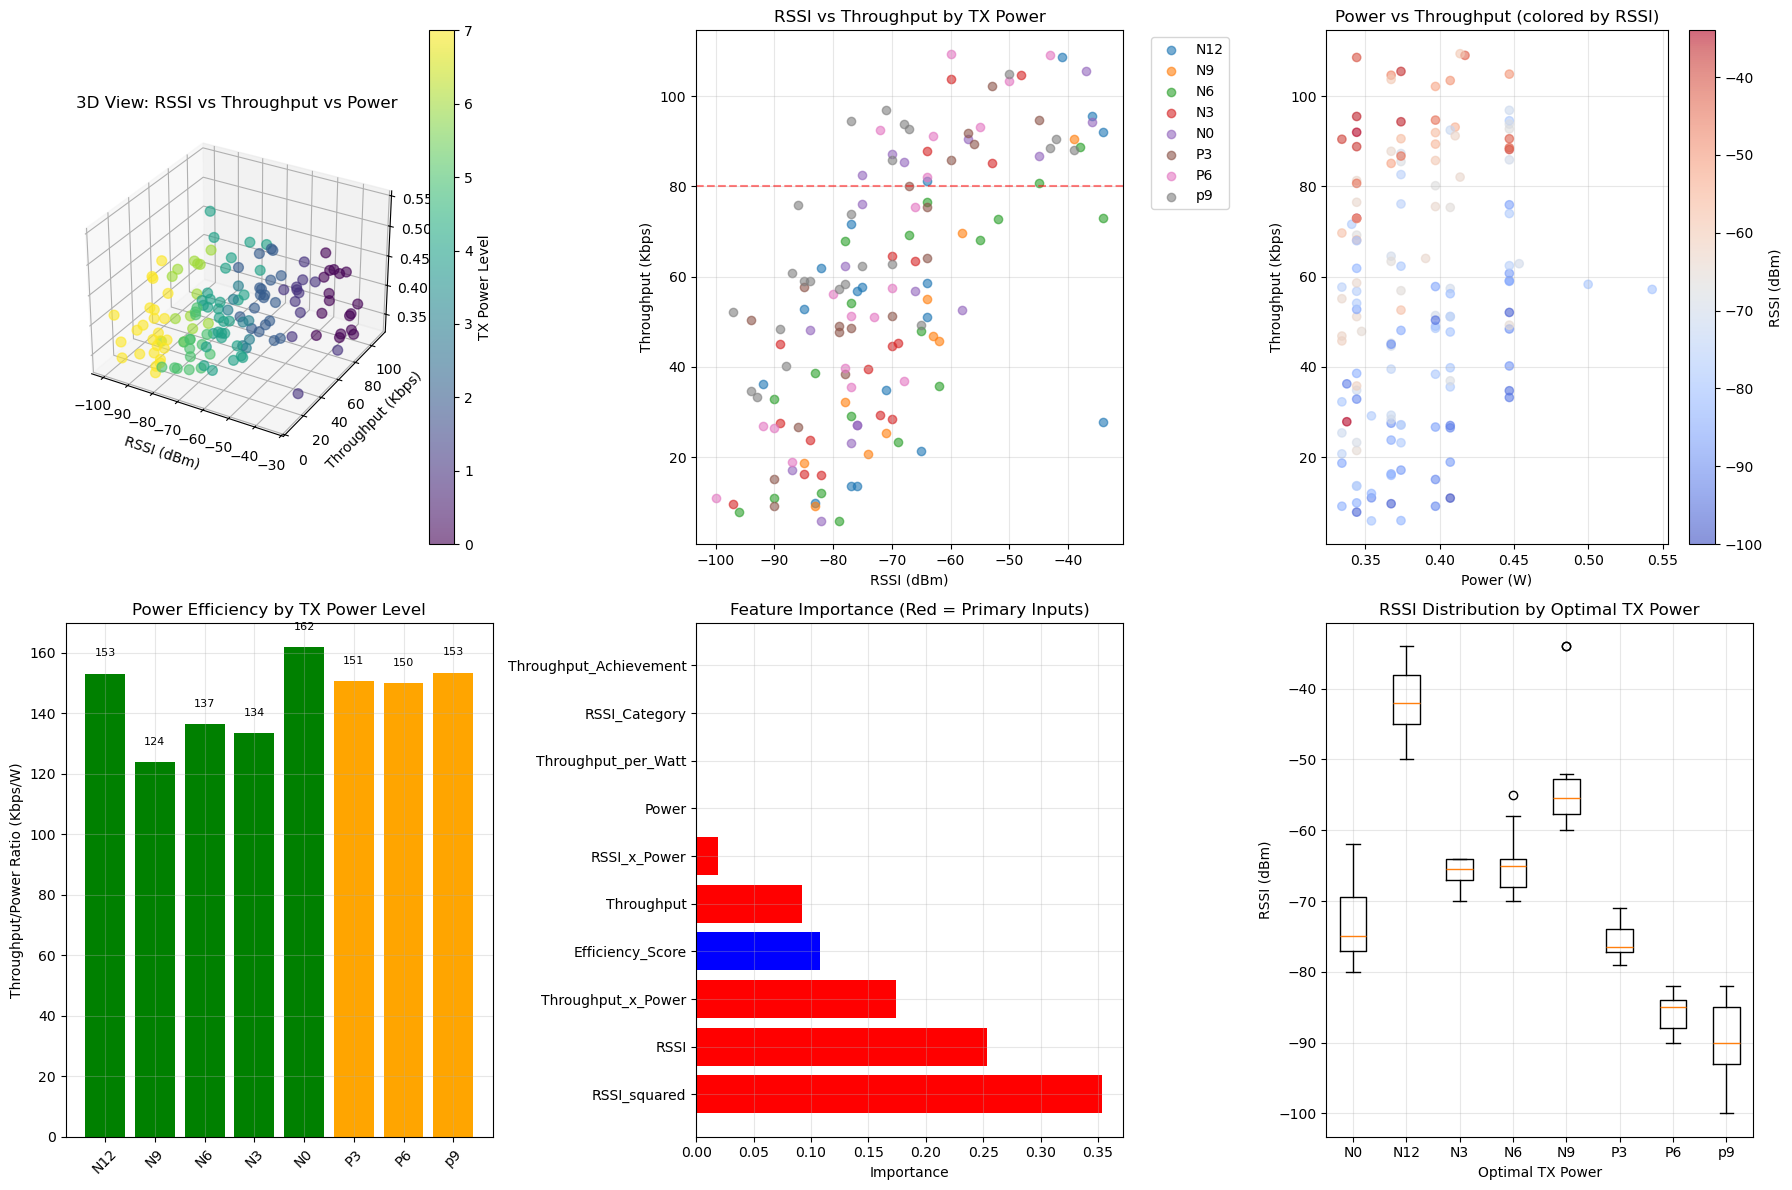


EXAMPLE PREDICTIONS (Using only RSSI, Throughput, Power)


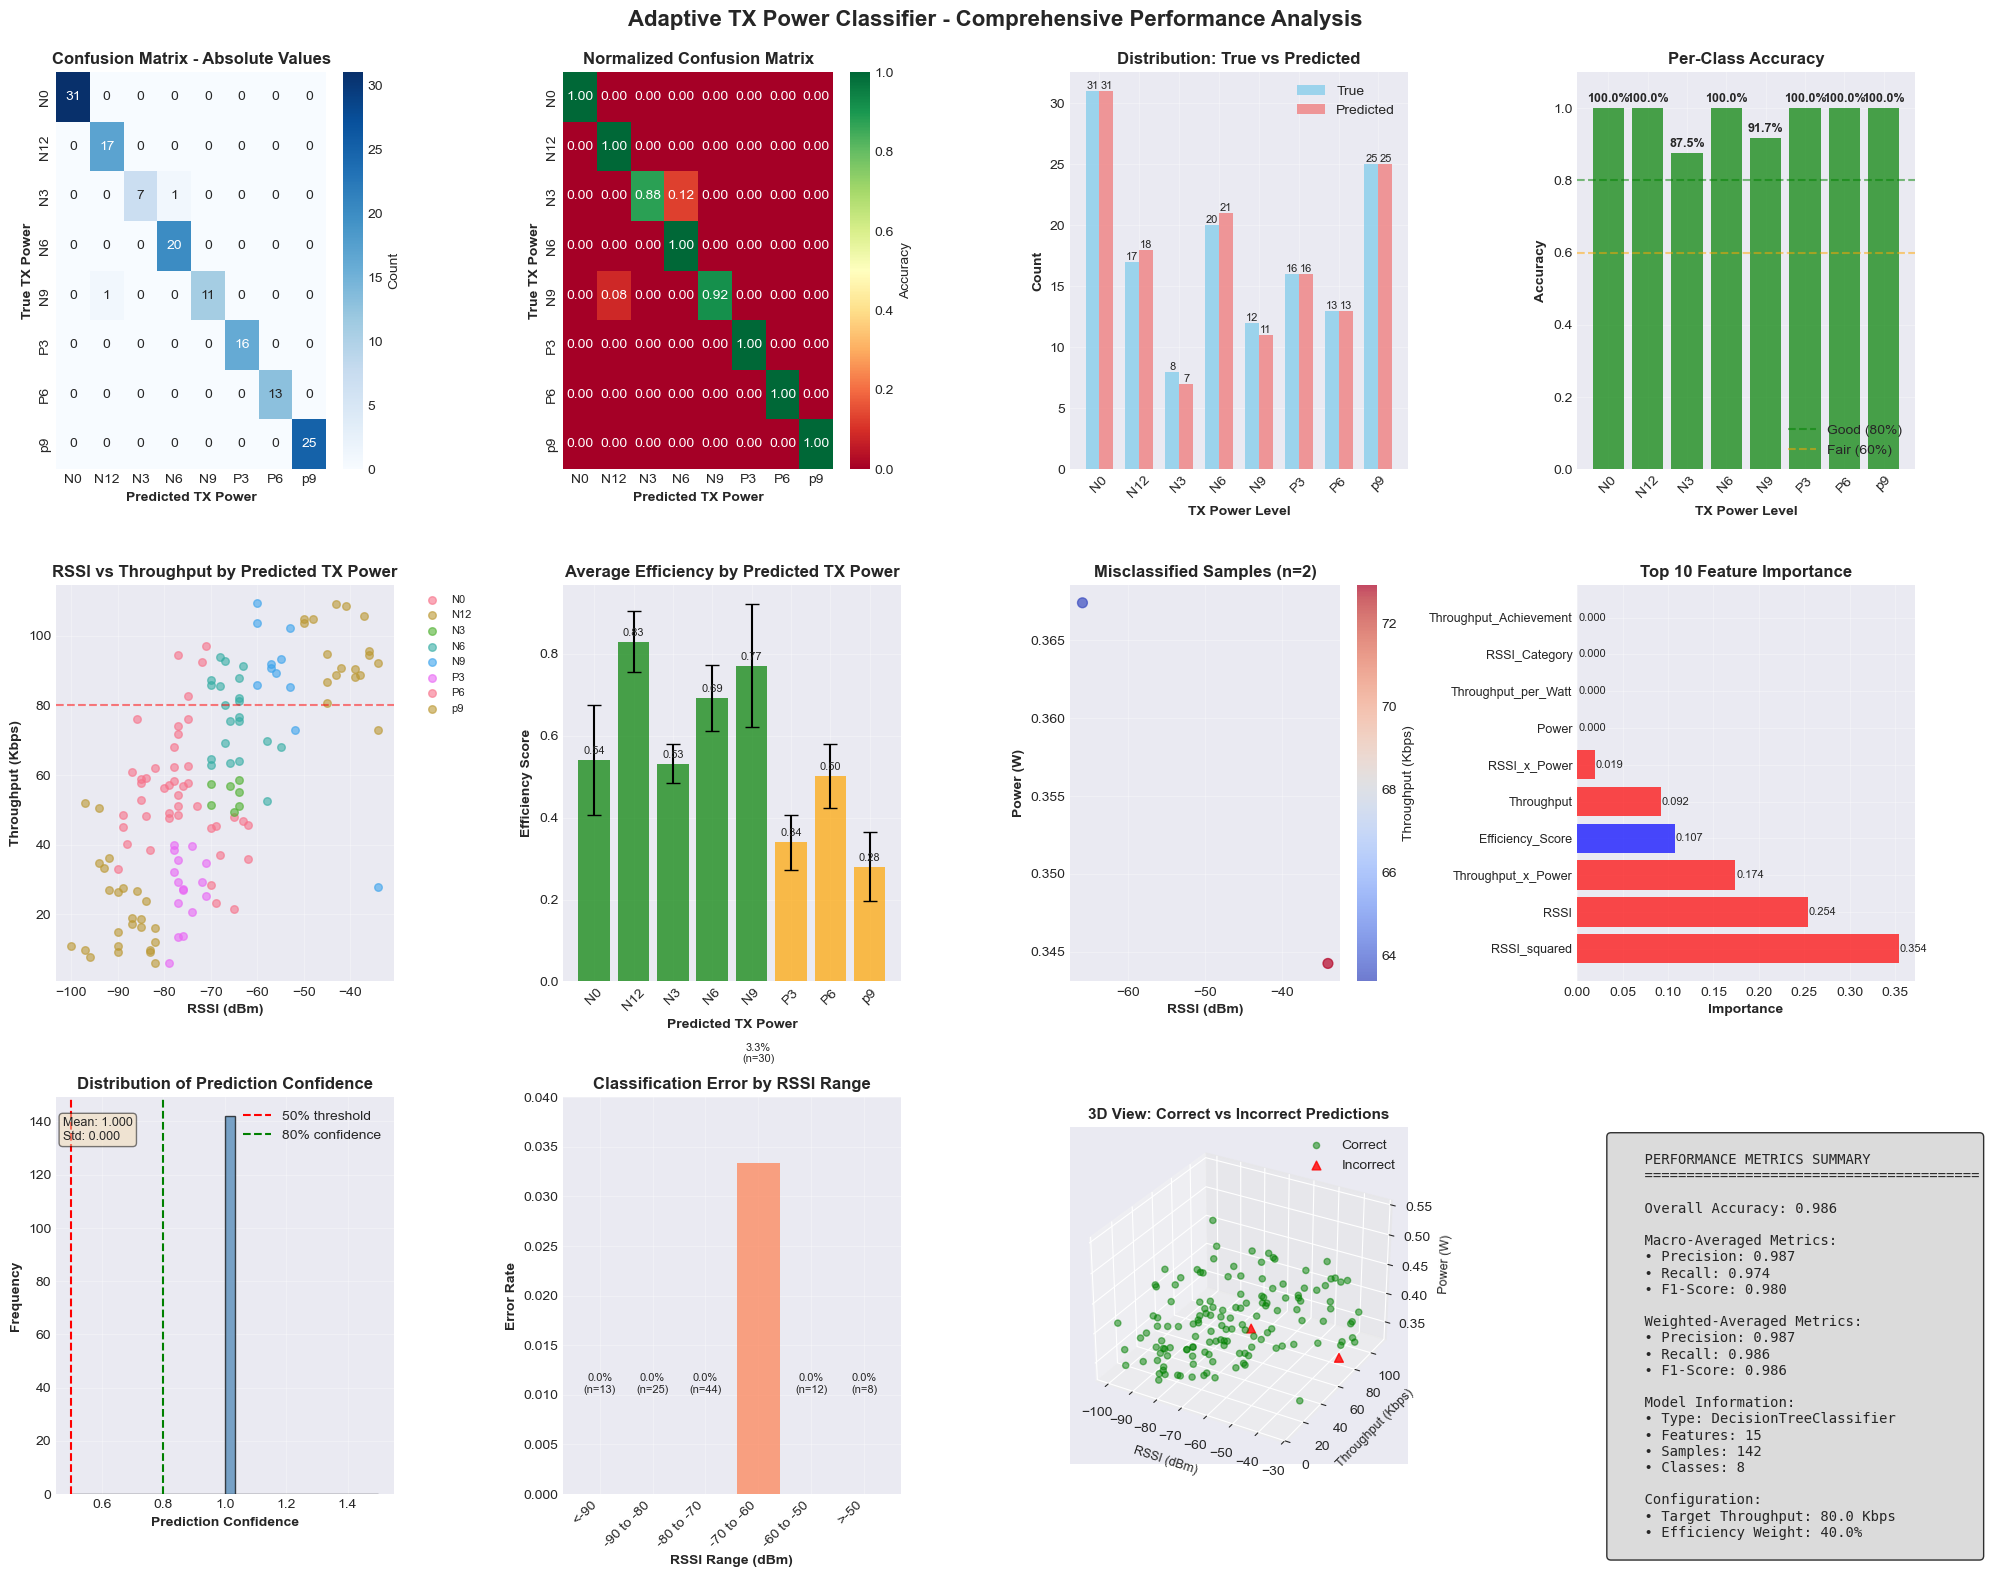

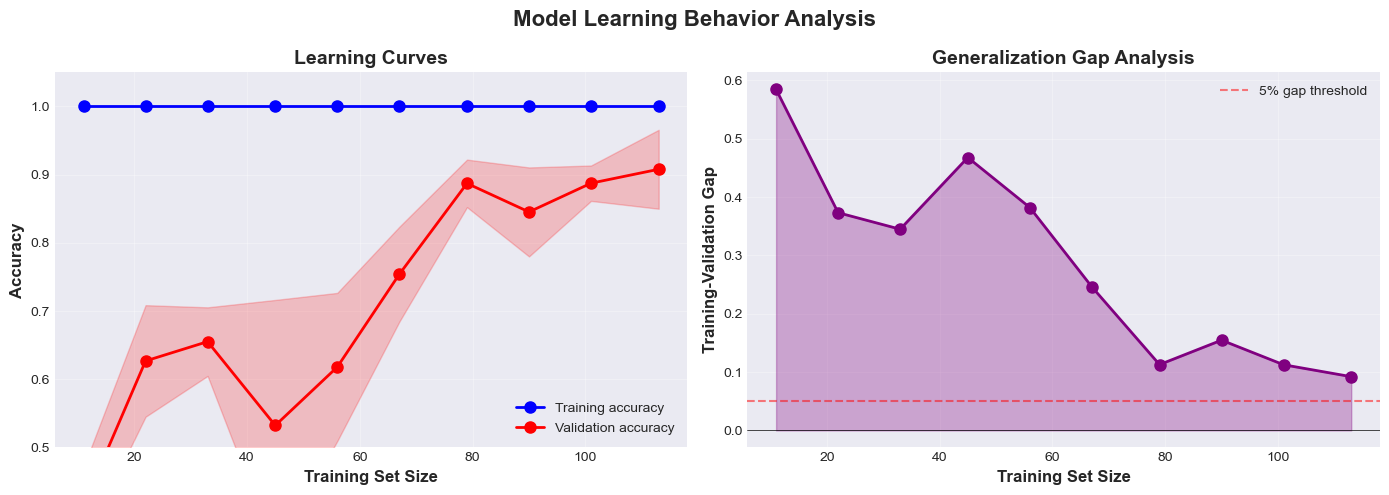


Input: RSSI=-45dBm, Throughput=95Kbps, Power=0.35W
  Efficiency Score: 0.858
  Recommended TX Power: N12
  Confidence: 100.00%
  Alternatives: N0(0.0%), N3(0.0%)

Input: RSSI=-65dBm, Throughput=70Kbps, Power=0.38W
  Efficiency Score: 0.649
  Recommended TX Power: N6
  Confidence: 100.00%
  Alternatives: N0(0.0%), N12(0.0%)

Input: RSSI=-75dBm, Throughput=50Kbps, Power=0.4W
  Efficiency Score: 0.484
  Recommended TX Power: N0
  Confidence: 100.00%
  Alternatives: N12(0.0%), N3(0.0%)

Input: RSSI=-85dBm, Throughput=30Kbps, Power=0.42W
  Efficiency Score: 0.320
  Recommended TX Power: P6
  Confidence: 100.00%
  Alternatives: N0(0.0%), N12(0.0%)

Input: RSSI=-95dBm, Throughput=10Kbps, Power=0.45W
  Efficiency Score: 0.148
  Recommended TX Power: p9
  Confidence: 100.00%
  Alternatives: N0(0.0%), N12(0.0%)

Input: RSSI=-55dBm, Throughput=100Kbps, Power=0.34W
  Efficiency Score: 0.903
  Recommended TX Power: N9
  Confidence: 100.00%
  Alternatives: N0(0.0%), N12(0.0%)

Input: RSSI=-70dBm, T

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

class AdaptiveTXPowerClassifier:
    def __init__(self, throughput_target=80.0, efficiency_weight=0.5):
        """
        Initialize the Adaptive TX Power Classifier
        
        Parameters:
        - throughput_target: Target throughput in Kbps (default: 80 Kbps)
        - efficiency_weight: Weight for power efficiency (0-1, higher = more emphasis on power saving)
        """
        self.throughput_target = throughput_target
        self.efficiency_weight = efficiency_weight
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.model = None
        self.feature_importance = None
        
    def load_and_prepare_data(self, file_path):
        """Load and prepare the dataset"""
        # Read CSV
        df = pd.read_csv(file_path)
        
        # Clean column names
        df.columns = df.columns.str.strip()
        
        # Extract TX power levels
        df['TX_Power_Numeric'] = df['Tx Power'].str.extract(r'([NP])(\d+)', expand=True)[1].astype(float)
        df['TX_Power_Type'] = df['Tx Power'].str.extract(r'([NP])', expand=True)[0]
        
        # Convert negative TX powers to positive for N type
        df.loc[df['TX_Power_Type'] == 'N', 'TX_Power_Numeric'] = -df.loc[df['TX_Power_Type'] == 'N', 'TX_Power_Numeric']
        
        # Clean numeric columns
        df['RSSI (dbm)'] = pd.to_numeric(df['RSSI (dbm)'], errors='coerce')
        df['Throughput (Kbps)'] = pd.to_numeric(df['Throughput (Kbps)'], errors='coerce')
        df['Power (W)'] = pd.to_numeric(df['Power (W)'], errors='coerce')
        
        # Remove rows with NaN values
        df = df.dropna(subset=['RSSI (dbm)', 'Throughput (Kbps)', 'Power (W)'])
        
        return df
    
    def calculate_efficiency_score(self, throughput, power):
        """Calculate efficiency score for given throughput and power"""
        # Normalize throughput (higher is better)
        throughput_score = throughput / self.throughput_target
        
        # Normalize power (lower is better, so we invert)
        # Assuming max power is around 0.55W based on the dataset
        power_score = 1 - (power / 0.55)
        
        # Weighted combination
        efficiency = (1 - self.efficiency_weight) * throughput_score + self.efficiency_weight * power_score
        
        return efficiency
    
    def determine_optimal_tx_power(self, df):
        """
        Determine optimal TX power based on RSSI, throughput, and power consumption
        Uses the principle: maximize throughput while minimizing power
        """
        optimal_powers = []
        
        for _, row in df.iterrows():
            rssi = row['RSSI (dbm)']
            throughput = row['Throughput (Kbps)']
            power = row['Power (W)']
            
            # Calculate efficiency score
            efficiency = self.calculate_efficiency_score(throughput, power)
            
            # Decision rules based on RSSI and efficiency
            if rssi >= -50:
                # Very strong signal - use lowest power
                if throughput >= self.throughput_target:
                    optimal_power = 'N12'
                else:
                    optimal_power = 'N9'
            elif rssi >= -60:
                # Strong signal
                if throughput >= self.throughput_target * 0.9:
                    optimal_power = 'N9'
                else:
                    optimal_power = 'N6'
            elif rssi >= -70:
                # Medium signal
                if throughput >= self.throughput_target * 0.8:
                    optimal_power = 'N6'
                elif throughput >= self.throughput_target * 0.6:
                    optimal_power = 'N3'
                else:
                    optimal_power = 'N0'
            elif rssi >= -80:
                # Weak signal
                if throughput >= self.throughput_target * 0.5:
                    optimal_power = 'N0'
                else:
                    optimal_power = 'P3'
            elif rssi >= -90:
                # Very weak signal
                if throughput < 30:  # Very low throughput
                    optimal_power = 'p9'
                else:
                    optimal_power = 'P6'
            else:
                # Extremely weak signal - use highest power
                optimal_power = 'p9'
            
            # Adjust based on power efficiency
            if power > 0.45 and throughput < self.throughput_target:
                # Using too much power without achieving target
                # Consider stepping down if signal is decent
                if rssi > -75:
                    current_idx = ['N12', 'N9', 'N6', 'N3', 'N0', 'P3', 'P6', 'p9'].index(optimal_power)
                    if current_idx > 0:
                        optimal_power = ['N12', 'N9', 'N6', 'N3', 'N0', 'P3', 'P6', 'p9'][max(0, current_idx - 1)]
            
            optimal_powers.append(optimal_power)
        
        return optimal_powers
    
    def create_features(self, df):
        """
        Create features for ML model - ONLY using RSSI, Throughput, and Power
        """
        features = pd.DataFrame()
        
        # Primary features (only these three inputs)
        features['RSSI'] = df['RSSI (dbm)']
        features['Throughput'] = df['Throughput (Kbps)']
        features['Power'] = df['Power (W)']
        
        # Derived features from the three inputs
        features['Throughput_per_Watt'] = features['Throughput'] / features['Power']
        features['RSSI_Category'] = pd.cut(features['RSSI'], 
                                           bins=[-np.inf, -90, -80, -70, -60, -50, np.inf],
                                           labels=[0, 1, 2, 3, 4, 5])
        features['Throughput_Achievement'] = features['Throughput'] / self.throughput_target
        features['Power_Efficiency'] = 1 - (features['Power'] / features['Power'].max())
        features['Signal_Strength_Score'] = (features['RSSI'] + 100) / 60  # Normalize RSSI to 0-1 range
        
        # Efficiency score combining all three inputs
        features['Efficiency_Score'] = features.apply(
            lambda x: self.calculate_efficiency_score(x['Throughput'], x['Power']), axis=1
        )
        
        # Quadratic features for better decision boundaries
        features['RSSI_squared'] = features['RSSI'] ** 2
        features['Throughput_squared'] = features['Throughput'] ** 2
        features['Power_squared'] = features['Power'] ** 2
        
        # Interaction features
        features['RSSI_x_Throughput'] = features['RSSI'] * features['Throughput']
        features['RSSI_x_Power'] = features['RSSI'] * features['Power']
        features['Throughput_x_Power'] = features['Throughput'] * features['Power']
        
        return features
    
    def train_model(self, X, y):
        """Train the classification model with hyperparameter tuning"""
        # Encode target labels
        y_encoded = self.label_encoder.fit_transform(y)
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
        )
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Train multiple models and select best
        models = {
            'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100),
            'GradientBoosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
            'NeuralNetwork': MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=(50, 30)),
            'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=10)
        }
        
        best_score = 0
        best_model = None
        best_name = None
        
        print("Training models with 3-input feature set (RSSI, Throughput, Power)...")
        print("-" * 60)
        for name, model in models.items():
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
            mean_score = cv_scores.mean()
            
            print(f"{name:20} CV Score: {mean_score:.3f} (+/- {cv_scores.std() * 2:.3f})")
            
            if mean_score > best_score:
                best_score = mean_score
                best_model = model
                best_name = name
        
        print(f"\nBest model: {best_name} with CV score: {best_score:.3f}")
        
        # Train best model with hyperparameter tuning
        if isinstance(best_model, RandomForestClassifier):
            param_grid = {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, 15, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
        elif isinstance(best_model, GradientBoostingClassifier):
            param_grid = {
                'n_estimators': [50, 100, 150],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 5, 7],
                'subsample': [0.8, 1.0]
            }
        elif isinstance(best_model, MLPClassifier):
            param_grid = {
                'hidden_layer_sizes': [(50,), (100,), (50, 30), (100, 50)],
                'learning_rate_init': [0.001, 0.01, 0.1],
                'alpha': [0.0001, 0.001, 0.01]
            }
        else:
            param_grid = {
                'max_depth': [5, 10, 15, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
        
        print("\nPerforming hyperparameter tuning...")
        grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train_scaled, y_train)
        
        self.model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        
        # Evaluate on test set
        y_pred = self.model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"\nTest Accuracy: {accuracy:.3f}")
        
        # Feature importance (for tree-based models)
        if hasattr(self.model, 'feature_importances_'):
            self.feature_importance = pd.DataFrame({
                'feature': X.columns,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
        
        # Detailed classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, 
                                   target_names=self.label_encoder.classes_))
        
        # Confusion Matrix
        print("\nConfusion Matrix:")
        cm = confusion_matrix(y_test, y_pred)
        print(cm)
        
        return self.model, accuracy
    
    def predict_tx_power(self, rssi, throughput, power):
        """
        Predict optimal TX power for given conditions
        Inputs: RSSI (dBm), Throughput (Kbps), Power consumption (W)
        """
        if self.model is None:
            raise ValueError("Model not trained yet!")
        
        # Create feature vector with only the three inputs
        feature_dict = {
            'RSSI': rssi,
            'Throughput': throughput,
            'Power': power,
            'Throughput_per_Watt': throughput / power,
            'RSSI_Category': 5 if rssi > -50 else 4 if rssi > -60 else 3 if rssi > -70 else 2 if rssi > -80 else 1 if rssi > -90 else 0,
            'Throughput_Achievement': throughput / self.throughput_target,
            'Power_Efficiency': 1 - (power / 0.55),
            'Signal_Strength_Score': (rssi + 100) / 60,
            'Efficiency_Score': self.calculate_efficiency_score(throughput, power),
            'RSSI_squared': rssi ** 2,
            'Throughput_squared': throughput ** 2,
            'Power_squared': power ** 2,
            'RSSI_x_Throughput': rssi * throughput,
            'RSSI_x_Power': rssi * power,
            'Throughput_x_Power': throughput * power
        }
        
        # Create DataFrame
        feature_df = pd.DataFrame([feature_dict])
        
        # Scale and predict
        features_scaled = self.scaler.transform(feature_df)
        prediction = self.model.predict(features_scaled)
        probability = self.model.predict_proba(features_scaled)[0]
        
        # Get predicted TX power
        predicted_power = self.label_encoder.inverse_transform(prediction)[0]
        
        # Get confidence scores for all TX powers
        tx_powers = self.label_encoder.classes_
        confidence_dict = {tx: prob for tx, prob in zip(tx_powers, probability)}
        
        return predicted_power, confidence_dict
    
    def plot_analysis(self, df):
        """Create visualization plots focusing on the three inputs"""
        fig = plt.figure(figsize=(18, 12))
        
        # Create 3D subplot for the three inputs
        ax1 = fig.add_subplot(231, projection='3d')
        
        # Color map for TX powers
        tx_power_colors = {
            'N12': 0, 'N9': 1, 'N6': 2, 'N3': 3,
            'N0': 4, 'P3': 5, 'P6': 6, 'p9': 7
        }
        colors = [tx_power_colors.get(tp, 0) for tp in df['Optimal_TX_Power']]
        
        scatter = ax1.scatter(df['RSSI (dbm)'], df['Throughput (Kbps)'], df['Power (W)'],
                            c=colors, cmap='viridis', s=50, alpha=0.6)
        ax1.set_xlabel('RSSI (dBm)')
        ax1.set_ylabel('Throughput (Kbps)')
        ax1.set_zlabel('Power (W)')
        ax1.set_title('3D View: RSSI vs Throughput vs Power')
        plt.colorbar(scatter, ax=ax1, label='TX Power Level')
        
        # 2. RSSI vs Throughput
        ax2 = fig.add_subplot(232)
        for tx_power in df['Tx Power'].unique():
            power_data = df[df['Tx Power'] == tx_power]
            ax2.scatter(power_data['RSSI (dbm)'], power_data['Throughput (Kbps)'], 
                       label=tx_power, alpha=0.6)
        ax2.set_xlabel('RSSI (dBm)')
        ax2.set_ylabel('Throughput (Kbps)')
        ax2.set_title('RSSI vs Throughput by TX Power')
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=self.throughput_target, color='r', linestyle='--', alpha=0.5, label=f'Target: {self.throughput_target}')
        
        # 3. Power Consumption vs Throughput
        ax3 = fig.add_subplot(233)
        scatter2 = ax3.scatter(df['Power (W)'], df['Throughput (Kbps)'], 
                             c=df['RSSI (dbm)'], cmap='coolwarm', alpha=0.6)
        ax3.set_xlabel('Power (W)')
        ax3.set_ylabel('Throughput (Kbps)')
        ax3.set_title('Power vs Throughput (colored by RSSI)')
        plt.colorbar(scatter2, ax=ax3, label='RSSI (dBm)')
        ax3.grid(True, alpha=0.3)
        
        # 4. Efficiency Analysis
        ax4 = fig.add_subplot(234)
        df['Efficiency'] = df['Throughput (Kbps)'] / df['Power (W)']
        tx_powers_ordered = ['N12', 'N9', 'N6', 'N3', 'N0', 'P3', 'P6', 'p9']
        efficiency_data = []
        for tx in tx_powers_ordered:
            if tx in df['Tx Power'].values:
                efficiency_data.append(df[df['Tx Power'] == tx]['Efficiency'].mean())
            else:
                efficiency_data.append(0)
        
        bars = ax4.bar(range(len(tx_powers_ordered)), efficiency_data, 
                      color=['green' if i < 5 else 'orange' for i in range(len(tx_powers_ordered))])
        ax4.set_xticks(range(len(tx_powers_ordered)))
        ax4.set_xticklabels(tx_powers_ordered, rotation=45)
        ax4.set_ylabel('Throughput/Power Ratio (Kbps/W)')
        ax4.set_title('Power Efficiency by TX Power Level')
        ax4.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, val in zip(bars, efficiency_data):
            if val > 0:
                ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        f'{val:.0f}', ha='center', va='bottom', fontsize=8)
        
        # 5. Feature Importance
        ax5 = fig.add_subplot(235)
        if self.feature_importance is not None:
            # Focus on top features
            top_features = self.feature_importance.head(10)
            colors = ['red' if 'RSSI' in f or 'Throughput' in f or 'Power' in f else 'blue' 
                     for f in top_features['feature']]
            ax5.barh(range(len(top_features)), top_features['importance'], color=colors)
            ax5.set_yticks(range(len(top_features)))
            ax5.set_yticklabels(top_features['feature'])
            ax5.set_xlabel('Importance')
            ax5.set_title('Feature Importance (Red = Primary Inputs)')
            ax5.grid(True, alpha=0.3)
        else:
            ax5.text(0.5, 0.5, 'Train model first to see feature importance', 
                    ha='center', va='center', transform=ax5.transAxes)
        
        # 6. RSSI Distribution by Optimal TX Power
        ax6 = fig.add_subplot(236)
        optimal_tx_powers = df['Optimal_TX_Power'].unique()
        rssi_by_tx = [df[df['Optimal_TX_Power'] == tx]['RSSI (dbm)'].values 
                      for tx in sorted(optimal_tx_powers)]
        bp = ax6.boxplot(rssi_by_tx, labels=sorted(optimal_tx_powers))
        ax6.set_xlabel('Optimal TX Power')
        ax6.set_ylabel('RSSI (dBm)')
        ax6.set_title('RSSI Distribution by Optimal TX Power')
        ax6.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def main():
    # Initialize classifier
    classifier = AdaptiveTXPowerClassifier(
        throughput_target=80.0,  # Target 80 Kbps
        efficiency_weight=0.4     # 40% weight on power efficiency, 60% on throughput
    )
    
    # Load and prepare data
    print("="*60)
    print("ADAPTIVE TX POWER CLASSIFIER - 3 INPUT MODEL")
    print("Inputs: RSSI (dBm), Throughput (Kbps), Power (W)")
    print("="*60)
    print("\nLoading and preparing data...")
    df = classifier.load_and_prepare_data('TX_Power_Distances_Dataset.csv')
    print(f"Loaded {len(df)} samples")
    
    # Determine optimal TX powers for training
    print("\nDetermining optimal TX powers based on efficiency...")
    df['Optimal_TX_Power'] = classifier.determine_optimal_tx_power(df)
    
    # Show distribution of optimal TX powers
    print("\nOptimal TX Power Distribution:")
    print(df['Optimal_TX_Power'].value_counts().sort_index())
    
    # Create features (only using RSSI, Throughput, Power)
    print("\nCreating features from 3 inputs...")
    X = classifier.create_features(df)
    y = df['Optimal_TX_Power']
    
    print(f"Feature set size: {X.shape}")
    print(f"Features created: {list(X.columns)}")
    
    # Train model
    print("\n" + "="*60)
    print("TRAINING ML MODEL")
    print("="*60)
    model, accuracy = classifier.train_model(X, y)
    
    # Visualize results
    print("\nGenerating analysis plots...")
    classifier.plot_analysis(df)
    
    # Example predictions with only 3 inputs
    print("\n" + "="*60)
    print("EXAMPLE PREDICTIONS (Using only RSSI, Throughput, Power)")
    print("="*60)
    visualize_classifier_results(classifier, df, X, y)
    plot_learning_curves(classifier, X, y)
    test_scenarios = [
        {'rssi': -45, 'throughput': 95, 'power': 0.35},
        {'rssi': -65, 'throughput': 70, 'power': 0.38},
        {'rssi': -75, 'throughput': 50, 'power': 0.40},
        {'rssi': -85, 'throughput': 30, 'power': 0.42},
        {'rssi': -95, 'throughput': 10, 'power': 0.45},
        {'rssi': -55, 'throughput': 100, 'power': 0.34},
        {'rssi': -70, 'throughput': 40, 'power': 0.44},
    ]
    
    for test in test_scenarios:
        predicted_power, confidence = classifier.predict_tx_power(
            test['rssi'], test['throughput'], test['power']
        )
        
        # Calculate efficiency for this configuration
        efficiency = classifier.calculate_efficiency_score(test['throughput'], test['power'])
        
        print(f"\nInput: RSSI={test['rssi']}dBm, Throughput={test['throughput']}Kbps, Power={test['power']}W")
        print(f"  Efficiency Score: {efficiency:.3f}")
        print(f"  Recommended TX Power: {predicted_power}")
        print(f"  Confidence: {confidence[predicted_power]:.2%}")
        
        # Show top 3 alternatives
        sorted_conf = sorted(confidence.items(), key=lambda x: x[1], reverse=True)[:3]
        print(f"  Alternatives: {', '.join([f'{tx}({conf:.1%})' for tx, conf in sorted_conf[1:]])}")
    
    # Performance summary
    print("\n" + "="*60)
    print("MODEL PERFORMANCE SUMMARY")
    print("="*60)
    print(f"Model Type: {type(model).__name__}")
    print(f"Test Accuracy: {accuracy:.3f}")
    print(f"Number of Features: {X.shape[1]} (derived from 3 inputs)")
    print(f"TX Power Classes: {list(classifier.label_encoder.classes_)}")
    print(f"Throughput Target: {classifier.throughput_target} Kbps")
    print(f"Efficiency Weight: {classifier.efficiency_weight:.1%} power, {1-classifier.efficiency_weight:.1%} throughput")
    
    return classifier

if __name__ == "__main__":
    classifier = main()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

class AdaptiveTXPowerClassifier:
    def __init__(self, throughput_target=80.0, efficiency_weight=0.5):
        """
        Initialize the Adaptive TX Power Classifier
        
        Parameters:
        - throughput_target: Target throughput in Kbps (default: 80 Kbps)
        - efficiency_weight: Weight for power efficiency (0-1, higher = more emphasis on power saving)
        """
        self.throughput_target = throughput_target
        self.efficiency_weight = efficiency_weight
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.model = None
        self.feature_importance = None
        
    def load_and_prepare_data(self, file_path):
        """Load and prepare the dataset"""
        # Read CSV
        df = pd.read_csv(file_path)
        
        # Clean column names
        df.columns = df.columns.str.strip()
        
        # Extract TX power levels
        df['TX_Power_Numeric'] = df['Tx Power'].str.extract(r'([NP])(\d+)', expand=True)[1].astype(float)
        df['TX_Power_Type'] = df['Tx Power'].str.extract(r'([NP])', expand=True)[0]
        
        # Convert negative TX powers to positive for N type
        df.loc[df['TX_Power_Type'] == 'N', 'TX_Power_Numeric'] = -df.loc[df['TX_Power_Type'] == 'N', 'TX_Power_Numeric']
        
        # Clean numeric columns
        df['RSSI (dbm)'] = pd.to_numeric(df['RSSI (dbm)'], errors='coerce')
        df['Throughput (Kbps)'] = pd.to_numeric(df['Throughput (Kbps)'], errors='coerce')
        df['Power (W)'] = pd.to_numeric(df['Power (W)'], errors='coerce')
        
        # Remove rows with NaN values
        df = df.dropna(subset=['RSSI (dbm)', 'Throughput (Kbps)', 'Power (W)'])
        
        return df
    
    def calculate_efficiency_score(self, throughput, power):
        """Calculate efficiency score for given throughput and power"""
        # Normalize throughput (higher is better)
        throughput_score = throughput / self.throughput_target
        
        # Normalize power (lower is better, so we invert)
        # Assuming max power is around 0.55W based on the dataset
        power_score = 1 - (power / 0.55)
        
        # Weighted combination
        efficiency = (1 - self.efficiency_weight) * throughput_score + self.efficiency_weight * power_score
        
        return efficiency
    
    def determine_optimal_tx_power(self, df):
        """
        Determine optimal TX power based on RSSI, throughput, and power consumption
        Uses the principle: maximize throughput while minimizing power
        """
        optimal_powers = []
        
        for _, row in df.iterrows():
            rssi = row['RSSI (dbm)']
            throughput = row['Throughput (Kbps)']
            power = row['Power (W)']
            
            # Calculate efficiency score
            efficiency = self.calculate_efficiency_score(throughput, power)
            
            # Decision rules based on RSSI and efficiency
            if rssi >= -50:
                # Very strong signal - use lowest power
                if throughput >= self.throughput_target:
                    optimal_power = 'N12'
                else:
                    optimal_power = 'N9'
            elif rssi >= -60:
                # Strong signal
                if throughput >= self.throughput_target * 0.9:
                    optimal_power = 'N9'
                else:
                    optimal_power = 'N6'
            elif rssi >= -70:
                # Medium signal
                if throughput >= self.throughput_target * 0.8:
                    optimal_power = 'N6'
                elif throughput >= self.throughput_target * 0.6:
                    optimal_power = 'N3'
                else:
                    optimal_power = 'N0'
            elif rssi >= -80:
                # Weak signal
                if throughput >= self.throughput_target * 0.5:
                    optimal_power = 'N0'
                else:
                    optimal_power = 'P3'
            elif rssi >= -90:
                # Very weak signal
                if throughput < 30:  # Very low throughput
                    optimal_power = 'p9'
                else:
                    optimal_power = 'P6'
            else:
                # Extremely weak signal - use highest power
                optimal_power = 'p9'
            
            # Adjust based on power efficiency
            if power > 0.45 and throughput < self.throughput_target:
                # Using too much power without achieving target
                # Consider stepping down if signal is decent
                if rssi > -75:
                    current_idx = ['N12', 'N9', 'N6', 'N3', 'N0', 'P3', 'P6', 'p9'].index(optimal_power)
                    if current_idx > 0:
                        optimal_power = ['N12', 'N9', 'N6', 'N3', 'N0', 'P3', 'P6', 'p9'][max(0, current_idx - 1)]
            
            optimal_powers.append(optimal_power)
        
        return optimal_powers
    
    def create_features(self, df):
        """
        Create features for ML model - ONLY using RSSI, Throughput, and Power
        """
        features = pd.DataFrame()
        
        # Primary features (only these three inputs)
        features['RSSI'] = df['RSSI (dbm)']
        features['Throughput'] = df['Throughput (Kbps)']
        features['Power'] = df['Power (W)']
        
        # Derived features from the three inputs
        features['Throughput_per_Watt'] = features['Throughput'] / features['Power']
        features['RSSI_Category'] = pd.cut(features['RSSI'], 
                                           bins=[-np.inf, -90, -80, -70, -60, -50, np.inf],
                                           labels=[0, 1, 2, 3, 4, 5])
        features['Throughput_Achievement'] = features['Throughput'] / self.throughput_target
        features['Power_Efficiency'] = 1 - (features['Power'] / features['Power'].max())
        features['Signal_Strength_Score'] = (features['RSSI'] + 100) / 60  # Normalize RSSI to 0-1 range
        
        # Efficiency score combining all three inputs
        features['Efficiency_Score'] = features.apply(
            lambda x: self.calculate_efficiency_score(x['Throughput'], x['Power']), axis=1
        )
        
        # Quadratic features for better decision boundaries
        features['RSSI_squared'] = features['RSSI'] ** 2
        features['Throughput_squared'] = features['Throughput'] ** 2
        features['Power_squared'] = features['Power'] ** 2
        
        # Interaction features
        features['RSSI_x_Throughput'] = features['RSSI'] * features['Throughput']
        features['RSSI_x_Power'] = features['RSSI'] * features['Power']
        features['Throughput_x_Power'] = features['Throughput'] * features['Power']
        
        return features
    
    def train_model(self, X, y):
        """Train the classification model with hyperparameter tuning"""
        # Encode target labels
        y_encoded = self.label_encoder.fit_transform(y)
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
        )
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Train multiple models and select best
        models = {
            'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100),
            'GradientBoosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
            'NeuralNetwork': MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=(50, 30)),
            'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=10)
        }
        
        best_score = 0
        best_model = None
        best_name = None
        
        print("Training models with 3-input feature set (RSSI, Throughput, Power)...")
        print("-" * 60)
        for name, model in models.items():
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
            mean_score = cv_scores.mean()
            
            print(f"{name:20} CV Score: {mean_score:.3f} (+/- {cv_scores.std() * 2:.3f})")
            
            if mean_score > best_score:
                best_score = mean_score
                best_model = model
                best_name = name
        
        print(f"\nBest model: {best_name} with CV score: {best_score:.3f}")
        
        # Train best model with hyperparameter tuning
        if isinstance(best_model, RandomForestClassifier):
            param_grid = {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, 15, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
        elif isinstance(best_model, GradientBoostingClassifier):
            param_grid = {
                'n_estimators': [50, 100, 150],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 5, 7],
                'subsample': [0.8, 1.0]
            }
        elif isinstance(best_model, MLPClassifier):
            param_grid = {
                'hidden_layer_sizes': [(50,), (100,), (50, 30), (100, 50)],
                'learning_rate_init': [0.001, 0.01, 0.1],
                'alpha': [0.0001, 0.001, 0.01]
            }
        else:
            param_grid = {
                'max_depth': [5, 10, 15, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
        
        print("\nPerforming hyperparameter tuning...")
        grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train_scaled, y_train)
        
        self.model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        
        # Evaluate on test set
        y_pred = self.model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"\nTest Accuracy: {accuracy:.3f}")
        
        # Feature importance (for tree-based models)
        if hasattr(self.model, 'feature_importances_'):
            self.feature_importance = pd.DataFrame({
                'feature': X.columns,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
        
        # Detailed classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, 
                                   target_names=self.label_encoder.classes_))
        
        # Confusion Matrix
        print("\nConfusion Matrix:")
        cm = confusion_matrix(y_test, y_pred)
        print(cm)
        
        return self.model, accuracy
    
    def predict_tx_power(self, rssi, throughput, power):
        """
        Predict optimal TX power for given conditions
        Inputs: RSSI (dBm), Throughput (Kbps), Power consumption (W)
        """
        if self.model is None:
            raise ValueError("Model not trained yet!")
        
        # Create feature vector with only the three inputs
        feature_dict = {
            'RSSI': rssi,
            'Throughput': throughput,
            'Power': power,
            'Throughput_per_Watt': throughput / power,
            'RSSI_Category': 5 if rssi > -50 else 4 if rssi > -60 else 3 if rssi > -70 else 2 if rssi > -80 else 1 if rssi > -90 else 0,
            'Throughput_Achievement': throughput / self.throughput_target,
            'Power_Efficiency': 1 - (power / 0.55),
            'Signal_Strength_Score': (rssi + 100) / 60,
            'Efficiency_Score': self.calculate_efficiency_score(throughput, power),
            'RSSI_squared': rssi ** 2,
            'Throughput_squared': throughput ** 2,
            'Power_squared': power ** 2,
            'RSSI_x_Throughput': rssi * throughput,
            'RSSI_x_Power': rssi * power,
            'Throughput_x_Power': throughput * power
        }
        
        # Create DataFrame
        feature_df = pd.DataFrame([feature_dict])
        
        # Scale and predict
        features_scaled = self.scaler.transform(feature_df)
        prediction = self.model.predict(features_scaled)
        probability = self.model.predict_proba(features_scaled)[0]
        
        # Get predicted TX power
        predicted_power = self.label_encoder.inverse_transform(prediction)[0]
        
        # Get confidence scores for all TX powers
        tx_powers = self.label_encoder.classes_
        confidence_dict = {tx: prob for tx, prob in zip(tx_powers, probability)}
        
        return predicted_power, confidence_dict
    
    def plot_analysis(self, df):
        """Create visualization plots focusing on the three inputs"""
        fig = plt.figure(figsize=(18, 12))
        
        # Create 3D subplot for the three inputs
        ax1 = fig.add_subplot(231, projection='3d')
        
        # Color map for TX powers
        tx_power_colors = {
            'N12': 0, 'N9': 1, 'N6': 2, 'N3': 3,
            'N0': 4, 'P3': 5, 'P6': 6, 'p9': 7
        }
        colors = [tx_power_colors.get(tp, 0) for tp in df['Optimal_TX_Power']]
        
        scatter = ax1.scatter(df['RSSI (dbm)'], df['Throughput (Kbps)'], df['Power (W)'],
                            c=colors, cmap='viridis', s=50, alpha=0.6)
        ax1.set_xlabel('RSSI (dBm)')
        ax1.set_ylabel('Throughput (Kbps)')
        ax1.set_zlabel('Power (W)')
        ax1.set_title('3D View: RSSI vs Throughput vs Power')
        plt.colorbar(scatter, ax=ax1, label='TX Power Level')
        
        # 2. RSSI vs Throughput
        ax2 = fig.add_subplot(232)
        for tx_power in df['Tx Power'].unique():
            power_data = df[df['Tx Power'] == tx_power]
            ax2.scatter(power_data['RSSI (dbm)'], power_data['Throughput (Kbps)'], 
                       label=tx_power, alpha=0.6)
        ax2.set_xlabel('RSSI (dBm)')
        ax2.set_ylabel('Throughput (Kbps)')
        ax2.set_title('RSSI vs Throughput by TX Power')
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=self.throughput_target, color='r', linestyle='--', alpha=0.5, label=f'Target: {self.throughput_target}')
        
        # 3. Power Consumption vs Throughput
        ax3 = fig.add_subplot(233)
        scatter2 = ax3.scatter(df['Power (W)'], df['Throughput (Kbps)'], 
                             c=df['RSSI (dbm)'], cmap='coolwarm', alpha=0.6)
        ax3.set_xlabel('Power (W)')
        ax3.set_ylabel('Throughput (Kbps)')
        ax3.set_title('Power vs Throughput (colored by RSSI)')
        plt.colorbar(scatter2, ax=ax3, label='RSSI (dBm)')
        ax3.grid(True, alpha=0.3)
        
        # 4. Efficiency Analysis
        ax4 = fig.add_subplot(234)
        df['Efficiency'] = df['Throughput (Kbps)'] / df['Power (W)']
        tx_powers_ordered = ['N12', 'N9', 'N6', 'N3', 'N0', 'P3', 'P6', 'p9']
        efficiency_data = []
        for tx in tx_powers_ordered:
            if tx in df['Tx Power'].values:
                efficiency_data.append(df[df['Tx Power'] == tx]['Efficiency'].mean())
            else:
                efficiency_data.append(0)
        
        bars = ax4.bar(range(len(tx_powers_ordered)), efficiency_data, 
                      color=['green' if i < 5 else 'orange' for i in range(len(tx_powers_ordered))])
        ax4.set_xticks(range(len(tx_powers_ordered)))
        ax4.set_xticklabels(tx_powers_ordered, rotation=45)
        ax4.set_ylabel('Throughput/Power Ratio (Kbps/W)')
        ax4.set_title('Power Efficiency by TX Power Level')
        ax4.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, val in zip(bars, efficiency_data):
            if val > 0:
                ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        f'{val:.0f}', ha='center', va='bottom', fontsize=8)
        
        # 5. Feature Importance
        ax5 = fig.add_subplot(235)
        if self.feature_importance is not None:
            # Focus on top features
            top_features = self.feature_importance.head(10)
            colors = ['red' if 'RSSI' in f or 'Throughput' in f or 'Power' in f else 'blue' 
                     for f in top_features['feature']]
            ax5.barh(range(len(top_features)), top_features['importance'], color=colors)
            ax5.set_yticks(range(len(top_features)))
            ax5.set_yticklabels(top_features['feature'])
            ax5.set_xlabel('Importance')
            ax5.set_title('Feature Importance (Red = Primary Inputs)')
            ax5.grid(True, alpha=0.3)
        else:
            ax5.text(0.5, 0.5, 'Train model first to see feature importance', 
                    ha='center', va='center', transform=ax5.transAxes)
        
        # 6. RSSI Distribution by Optimal TX Power
        ax6 = fig.add_subplot(236)
        optimal_tx_powers = df['Optimal_TX_Power'].unique()
        rssi_by_tx = [df[df['Optimal_TX_Power'] == tx]['RSSI (dbm)'].values 
                      for tx in sorted(optimal_tx_powers)]
        bp = ax6.boxplot(rssi_by_tx, labels=sorted(optimal_tx_powers))
        ax6.set_xlabel('Optimal TX Power')
        ax6.set_ylabel('RSSI (dBm)')
        ax6.set_title('RSSI Distribution by Optimal TX Power')
        ax6.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def main():
    # Initialize classifier
    classifier = AdaptiveTXPowerClassifier(
        throughput_target=80.0,  # Target 80 Kbps
        efficiency_weight=0.4     # 40% weight on power efficiency, 60% on throughput
    )
    
    # Load and prepare data
    print("="*60)
    print("ADAPTIVE TX POWER CLASSIFIER - 3 INPUT MODEL")
    print("Inputs: RSSI (dBm), Throughput (Kbps), Power (W)")
    print("="*60)
    print("\nLoading and preparing data...")
    df = classifier.load_and_prepare_data('synthetic_tx_power_data_1763517810185.csv')
    print(f"Loaded {len(df)} samples")
    
    # Determine optimal TX powers for training
    print("\nDetermining optimal TX powers based on efficiency...")
    df['Optimal_TX_Power'] = classifier.determine_optimal_tx_power(df)
    
    # Show distribution of optimal TX powers
    print("\nOptimal TX Power Distribution:")
    print(df['Optimal_TX_Power'].value_counts().sort_index())
    
    # Create features (only using RSSI, Throughput, Power)
    print("\nCreating features from 3 inputs...")
    X = classifier.create_features(df)
    y = df['Optimal_TX_Power']
    
    print(f"Feature set size: {X.shape}")
    print(f"Features created: {list(X.columns)}")
    
    # Train model
    print("\n" + "="*60)
    print("TRAINING ML MODEL")
    print("="*60)
    model, accuracy = classifier.train_model(X, y)
    
    # Visualize results
    print("\nGenerating analysis plots...")
    classifier.plot_analysis(df)
    
    # Example predictions with only 3 inputs
    print("\n" + "="*60)
    print("EXAMPLE PREDICTIONS (Using only RSSI, Throughput, Power)")
    print("="*60)

    test_scenarios = [
        {'rssi': -45, 'throughput': 95, 'power': 0.35},
        {'rssi': -65, 'throughput': 70, 'power': 0.38},
        {'rssi': -75, 'throughput': 50, 'power': 0.40},
        {'rssi': -85, 'throughput': 30, 'power': 0.42},
        {'rssi': -95, 'throughput': 10, 'power': 0.45},
        {'rssi': -55, 'throughput': 100, 'power': 0.34},
        {'rssi': -70, 'throughput': 40, 'power': 0.44},
    ]
    
    for test in test_scenarios:
        predicted_power, confidence = classifier.predict_tx_power(
            test['rssi'], test['throughput'], test['power']
        )
        
        # Calculate efficiency for this configuration
        efficiency = classifier.calculate_efficiency_score(test['throughput'], test['power'])
        
        print(f"\nInput: RSSI={test['rssi']}dBm, Throughput={test['throughput']}Kbps, Power={test['power']}W")
        print(f"  Efficiency Score: {efficiency:.3f}")
        print(f"  Recommended TX Power: {predicted_power}")
        print(f"  Confidence: {confidence[predicted_power]:.2%}")
        
        # Show top 3 alternatives
        sorted_conf = sorted(confidence.items(), key=lambda x: x[1], reverse=True)[:3]
        print(f"  Alternatives: {', '.join([f'{tx}({conf:.1%})' for tx, conf in sorted_conf[1:]])}")
    
    # Performance summary
    print("\n" + "="*60)
    print("MODEL PERFORMANCE SUMMARY")
    print("="*60)
    print(f"Model Type: {type(model).__name__}")
    print(f"Test Accuracy: {accuracy:.3f}")
    print(f"Number of Features: {X.shape[1]} (derived from 3 inputs)")
    print(f"TX Power Classes: {list(classifier.label_encoder.classes_)}")
    print(f"Throughput Target: {classifier.throughput_target} Kbps")
    print(f"Efficiency Weight: {classifier.efficiency_weight:.1%} power, {1-classifier.efficiency_weight:.1%} throughput")
    
    return classifier
if __name__ == "__main__":
    classifier = main()


ADAPTIVE TX POWER CLASSIFIER - 3 INPUT MODEL
Inputs: RSSI (dBm), Throughput (Kbps), Power (W)

Loading and preparing data...
Loaded 10000 samples

Determining optimal TX powers based on efficiency...

Optimal TX Power Distribution:
Optimal_TX_Power
N0     1136
N12     478
N3      367
N6      719
N9      587
P3     1314
P6       48
p9     5351
Name: count, dtype: int64

Creating features from 3 inputs...
Feature set size: (10000, 15)
Features created: ['RSSI', 'Throughput', 'Power', 'Throughput_per_Watt', 'RSSI_Category', 'Throughput_Achievement', 'Power_Efficiency', 'Signal_Strength_Score', 'Efficiency_Score', 'RSSI_squared', 'Throughput_squared', 'Power_squared', 'RSSI_x_Throughput', 'RSSI_x_Power', 'Throughput_x_Power']

TRAINING ML MODEL
Training models with 3-input feature set (RSSI, Throughput, Power)...
------------------------------------------------------------
RandomForest         CV Score: 1.000 (+/- 0.000)


KeyboardInterrupt: 